In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')
print(f"\nDataset loaded!")


Dataset loaded!


In [30]:
print(f"   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(df.head())

   Rows: 15509  |  Columns: 10
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Anga

In [31]:
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())


Column Names:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Basic Statistics:
            Rating

In [32]:
task_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']
df = df[task_cols].copy()

print("\n Selected task columns:")
print("   Genre    - Movie genre (Action, Drama, etc.)")
print("   Director - Movie director name")
print("   Actor 1  - Lead actor")
print("   Actor 2  - Supporting actor")
print("   Actor 3  - Supporting actor")
print("   Rating   - Target variable (what we predict)")


 Selected task columns:
   Genre    - Movie genre (Action, Drama, etc.)
   Director - Movie director name
   Actor 1  - Lead actor
   Actor 2  - Supporting actor
   Actor 3  - Supporting actor
   Rating   - Target variable (what we predict)


In [33]:
print("\nMissing values in task columns:")
print(df.isnull().sum())


Missing values in task columns:
Genre       1877
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
Rating      7590
dtype: int64



Generating EDA charts...


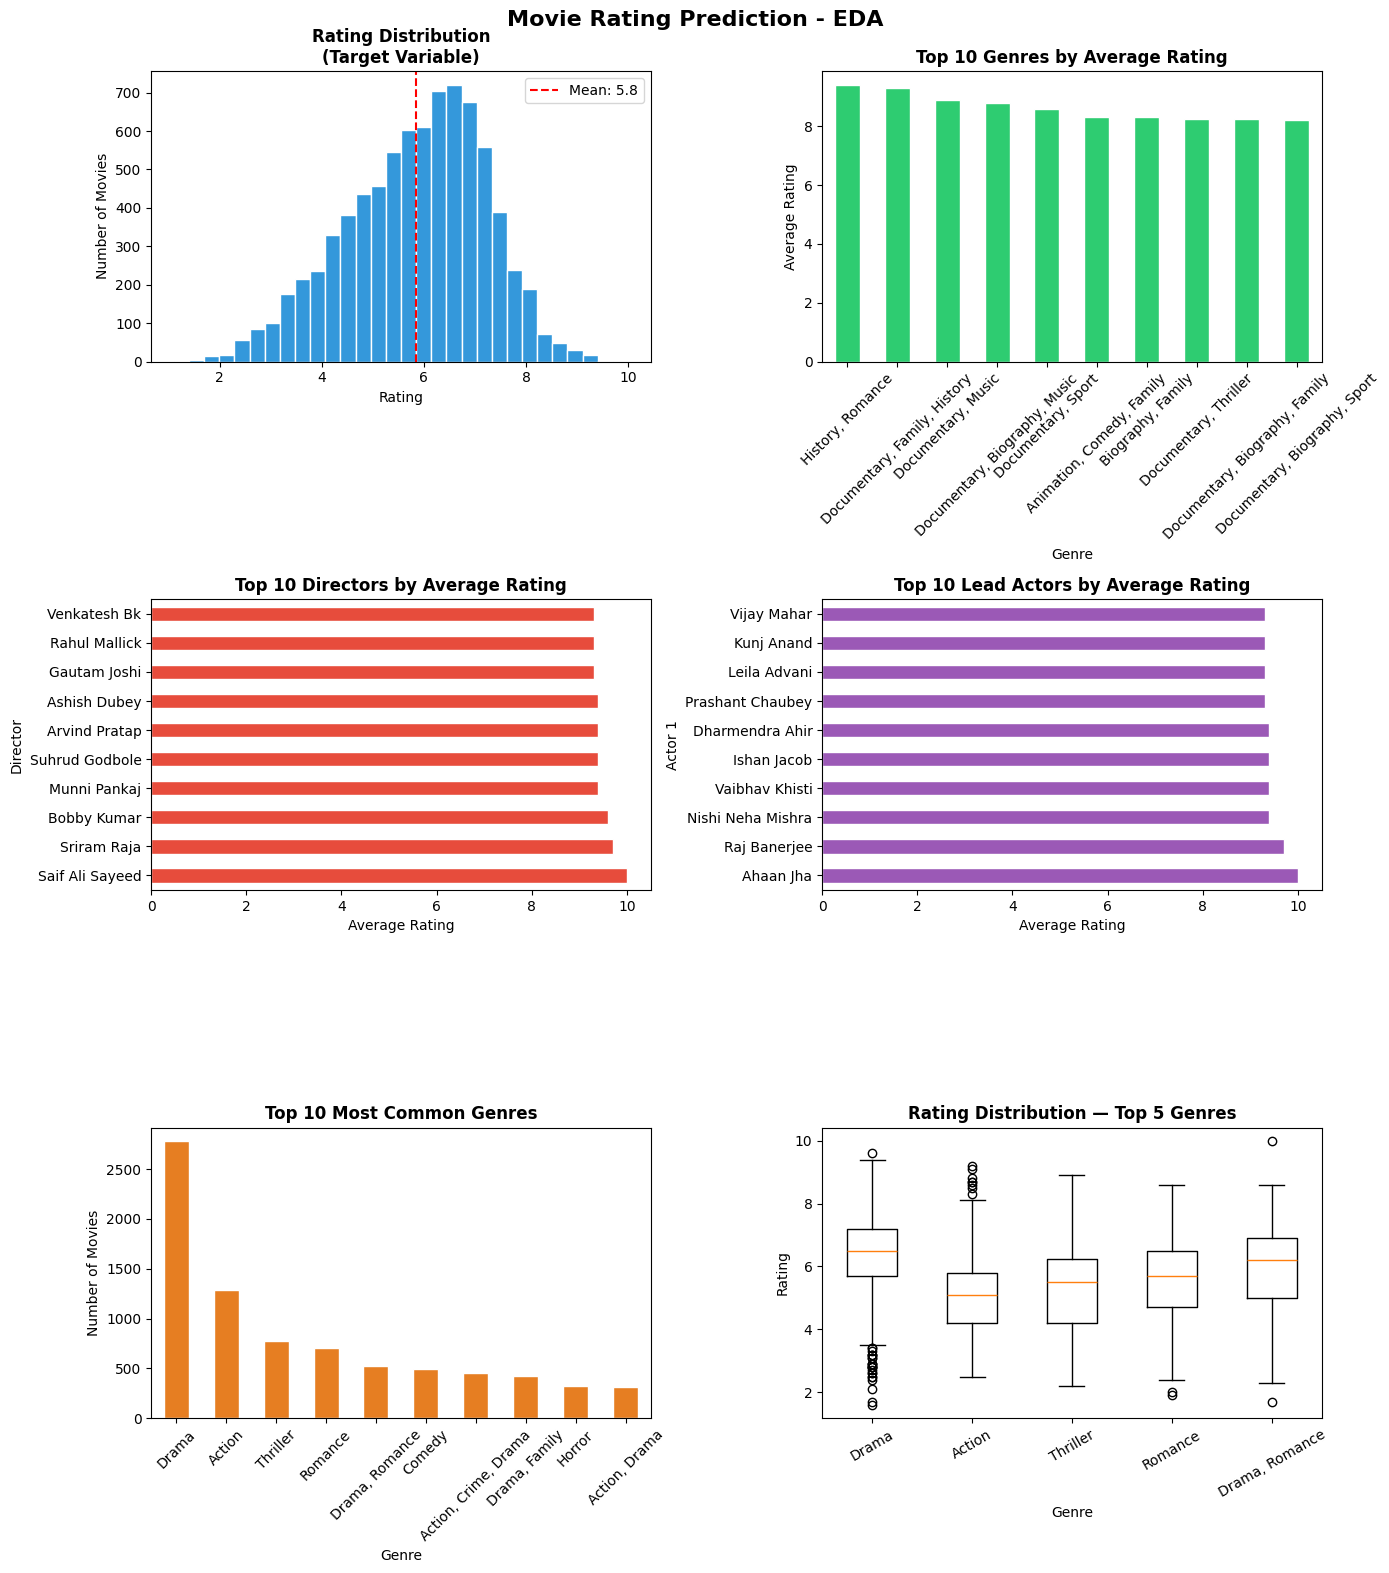

In [34]:
print("\nGenerating EDA charts...")

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Movie Rating Prediction - EDA',
             fontsize=16, fontweight='bold')

# Rating Distribution
axes[0,0].hist(df['Rating'].dropna(), bins=30,
               color='#3498db', edgecolor='white')
axes[0,0].set_title('Rating Distribution\n(Target Variable)', fontweight='bold')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Number of Movies')
axes[0,0].axvline(df['Rating'].mean(), color='red',
                   linestyle='--', label=f"Mean: {df['Rating'].mean():.1f}")
axes[0,0].legend()

# Average Rating by Genre
genre_rating = (df.groupby('Genre')['Rating']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))
genre_rating.plot(kind='bar', ax=axes[0,1],
                  color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Top 10 Genres by Average Rating', fontweight='bold')
axes[0,1].set_xlabel('Genre')
axes[0,1].set_ylabel('Average Rating')
axes[0,1].tick_params(axis='x', rotation=45)

# Top 10 Directors by Average Rating
director_rating = (df.groupby('Director')['Rating']
                     .mean()
                     .sort_values(ascending=False)
                     .head(10))
director_rating.plot(kind='barh', ax=axes[1,0],
                     color='#e74c3c', edgecolor='white')
axes[1,0].set_title('Top 10 Directors by Average Rating', fontweight='bold')
axes[1,0].set_xlabel('Average Rating')

# Top 10 Actors by Average Rating
actor_rating = (df.groupby('Actor 1')['Rating']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))
actor_rating.plot(kind='barh', ax=axes[1,1],
                  color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Top 10 Lead Actors by Average Rating', fontweight='bold')
axes[1,1].set_xlabel('Average Rating')

#  Movie Count by Genre (top 10)
genre_count = df['Genre'].value_counts().head(10)
genre_count.plot(kind='bar', ax=axes[2,0],
                 color='#e67e22', edgecolor='white')
axes[2,0].set_title('Top 10 Most Common Genres', fontweight='bold')
axes[2,0].set_xlabel('Genre')
axes[2,0].set_ylabel('Number of Movies')
axes[2,0].tick_params(axis='x', rotation=45)

# Rating Boxplot by top 5 genres
top5_genres = df['Genre'].value_counts().head(5).index
df_top5 = df[df['Genre'].isin(top5_genres)]
genre_groups = [df_top5[df_top5['Genre']==g]['Rating'].dropna().values
                for g in top5_genres]
axes[2,1].boxplot(genre_groups, labels=top5_genres)
axes[2,1].set_title('Rating Distribution — Top 5 Genres', fontweight='bold')
axes[2,1].set_xlabel('Genre')
axes[2,1].set_ylabel('Rating')
axes[2,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('movie_rating_eda.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
print(" EDA charts saved as movie_rating_eda.png!")
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col].fillna('Unknown', inplace=True)
    print(" Missing values filled with 'Unknown'):")
    print("\n Feature Engineering (Target Encoding):")

# Genre avg rating
genre_avg = df.groupby('Genre')['Rating'].mean()
df['Genre_encoded'] = df['Genre'].map(genre_avg)
print("   Genre    → encoded using average rating per genre")

# Director avg rating
director_avg = df.groupby('Director')['Rating'].mean()
df['Director_encoded'] = df['Director'].map(director_avg)
print("   Director → encoded using average rating per director")

# Actor 1 avg rating
actor1_avg = df.groupby('Actor 1')['Rating'].mean()
df['Actor1_encoded'] = df['Actor 1'].map(actor1_avg)
print("   Actor 1  → encoded using average rating per actor")

# Actor 2 avg rating
actor2_avg = df.groupby('Actor 2')['Rating'].mean()
df['Actor2_encoded'] = df['Actor 2'].map(actor2_avg)
print("   Actor 2  → encoded using average rating per actor")

# Actor 3 avg rating
actor3_avg = df.groupby('Actor 3')['Rating'].mean()
df['Actor3_encoded'] = df['Actor 3'].map(actor3_avg)
print("   Actor 3  → encoded using average rating per actor")
df.fillna(df.mean(numeric_only=True), inplace=True)
print(f"\nFinal dataset shape: {df.shape}")
print(f"Missing values left: {df.isnull().sum().sum()}")
print("\nPreprocessed data preview:")
print(df[['Genre', 'Genre_encoded', 'Director',
          'Director_encoded', 'Rating']].head())


 EDA charts saved as movie_rating_eda.png!
 Missing values filled with 'Unknown'):

 Feature Engineering (Target Encoding):
 Missing values filled with 'Unknown'):

 Feature Engineering (Target Encoding):
 Missing values filled with 'Unknown'):

 Feature Engineering (Target Encoding):
 Missing values filled with 'Unknown'):

 Feature Engineering (Target Encoding):
 Missing values filled with 'Unknown'):

 Feature Engineering (Target Encoding):
   Genre    → encoded using average rating per genre
   Director → encoded using average rating per director
   Actor 1  → encoded using average rating per actor
   Actor 2  → encoded using average rating per actor
   Actor 3  → encoded using average rating per actor

Final dataset shape: (15509, 11)
Missing values left: 0

Preprocessed data preview:
             Genre  Genre_encoded            Director  Director_encoded  \
0            Drama       6.352082       J.S. Randhawa          5.700000   
1            Drama       6.352082       Gaurav Ba

In [36]:
X = df[['Genre_encoded', 'Director_encoded',
        'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']]
y = df['Rating']

In [37]:

print("Features (X):")
print("Genre_encoded    - Average rating of that genre")
print("Director_encoded - Average rating of that director")
print("Actor1_encoded   - Average rating of lead actor")
print("Actor2_encoded   - Average rating of actor 2")
print("Actor3_encoded   - Average rating of actor 3")
print("Target (y): Rating")

Features (X):
Genre_encoded    - Average rating of that genre
Director_encoded - Average rating of that director
Actor1_encoded   - Average rating of lead actor
Actor2_encoded   - Average rating of actor 2
Actor3_encoded   - Average rating of actor 3
Target (y): Rating


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n Training samples: {X_train.shape[0]}")
print(f"Testing  samples: {X_test.shape[0]}")


 Training samples: 12407
Testing  samples: 3102


In [39]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Regression Metrics
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

print(f"\n Model   : Random Forest Regressor (Regression Technique)")
print(f"\n Model Performance:")
print(f"MAE  (Mean Absolute Error) : {mae:.2f}")
print(f"RMSE (Root Mean Sq Error)  : {rmse:.2f}")
print(f"R²   (R-squared Score)     : {r2:.2f}")
print(f"\n R² of {r2:.2f} means model explains {r2*100:.0f}% of rating variation")
print(f"On average, prediction is off by only {mae:.2f} rating points")


 Model   : Random Forest Regressor (Regression Technique)

 Model Performance:
MAE  (Mean Absolute Error) : 0.32
RMSE (Root Mean Sq Error)  : 0.56
R²   (R-squared Score)     : 0.67

 R² of 0.67 means model explains 67% of rating variation
On average, prediction is off by only 0.32 rating points


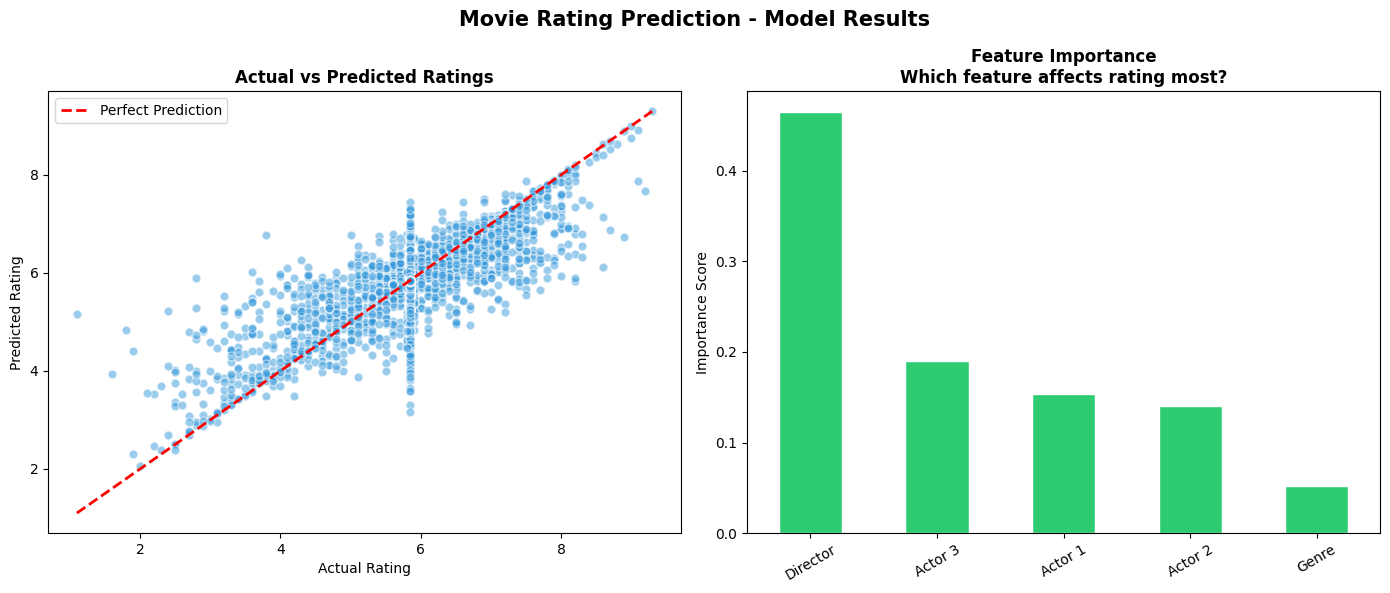

Result charts saved as movie_rating_results.png!

Feature Importance:
Director  : 0.4645|||||||||||||||||||||||
Actor 3   : 0.1903|||||||||
Actor 1   : 0.1532|||||||
Actor 2   : 0.1405|||||||
Genre     : 0.0515||


In [40]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Movie Rating Prediction - Model Results',
             fontsize=15, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, predictions, alpha=0.5,
                color='#3498db', edgecolor='white', s=40)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Ratings', fontweight='bold')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()

feat_imp = pd.Series(model.feature_importances_,
                     index=['Genre', 'Director',
                            'Actor 1', 'Actor 2', 'Actor 3']
                     ).sort_values(ascending=False)
feat_imp.plot(kind='bar', ax=axes[1],
              color='#2ecc71', edgecolor='white')
axes[1].set_title('Feature Importance\nWhich feature affects rating most?',
                   fontweight='bold')
axes[1].set_ylabel('Importance Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('movie_rating_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Result charts saved as movie_rating_results.png!")

print("\nFeature Importance:")
for feat, score in feat_imp.items():
    bar = '|' * int(score * 50)
    print(f"{feat:<10}: {score:.4f}{bar}")


In [41]:
def predict_movie(genre, director, actor1, actor2, actor3):
    g  = genre_avg.get(genre, genre_avg.mean())
    d  = director_avg.get(director, director_avg.mean())
    a1 = actor1_avg.get(actor1, actor1_avg.mean())
    a2 = actor2_avg.get(actor2, actor2_avg.mean())
    a3 = actor3_avg.get(actor3, actor3_avg.mean())

    features = pd.DataFrame([[g, d, a1, a2, a3]],
                             columns=X.columns)
    pred = model.predict(features)[0]
    return round(pred, 1)

# Test predictions
test_movies = [
    ("Action",  "Rajkumar Hirani", "Aamir Khan",  "Kareena Kapoor", "Boman Irani"),
    ("Drama",   "Anurag Kashyap",  "Nawazuddin Siddiqui", "Richa Chadha", "Pankaj Tripathi"),
    ("Comedy",  "David Dhawan",    "Salman Khan", "Govinda",        "Sanjay Mishra"),
    ("Romance", "Karan Johar",     "Shah Rukh Khan", "Kajol",       "Rani Mukerji"),
]


In [42]:

print(f"\n{'Genre':<10} {'Director':<22} {'Lead Actor':<25} Predicted Rating")
print("-" * 75)
for genre, director, a1, a2, a3 in test_movies:
    rating = predict_movie(genre, director, a1, a2, a3)
    stars  = '*' * int(rating)
    print(f"{genre:<10} {director:<22} {a1:<25}  {rating}/10  {stars}")


Genre      Director               Lead Actor                Predicted Rating
---------------------------------------------------------------------------
Action     Rajkumar Hirani        Aamir Khan                 6.9/10  ******
Drama      Anurag Kashyap         Nawazuddin Siddiqui        7.0/10  *******
Comedy     David Dhawan           Salman Khan                5.1/10  *****
Romance    Karan Johar            Shah Rukh Khan             6.9/10  ******
